___

<a href='https://www.udemy.com/user/joseportilla/'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Copyright by Pierian Data Inc.</em></center>
<center><em>For more information, visit us at <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# Random Forest - Regression
## Plus: An Additional Analysis of Various Regression Methods!

## The Data

We just got hired by a tunnel boring company which uses X-rays in an attempt to know rock density, ideally this will allow them to switch out boring heads on their equipment before having to mine through the rock!

<img src='boring.jpg' height=400>

They have given us some lab test results of signal strength returned in nHz to their sensors for various rock density types tested. You will notice it has almost a sine wave like relationship, where signal strength oscillates based off the density, the researchers are unsure why this is, but

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../DATA/rock_density_xray.csv")

In [3]:
df.head()

,Rebound Signal Strength nHz,Rock Density kg/m3
0,72.945124,2.456548
1,14.229877,2.601719
2,36.597334,1.967004
3,9.578899,2.300439
4,21.765897,2.452374


In [4]:
df.columns=['Signal',"Density"]

<Axes: xlabel='Signal', ylabel='Density'>

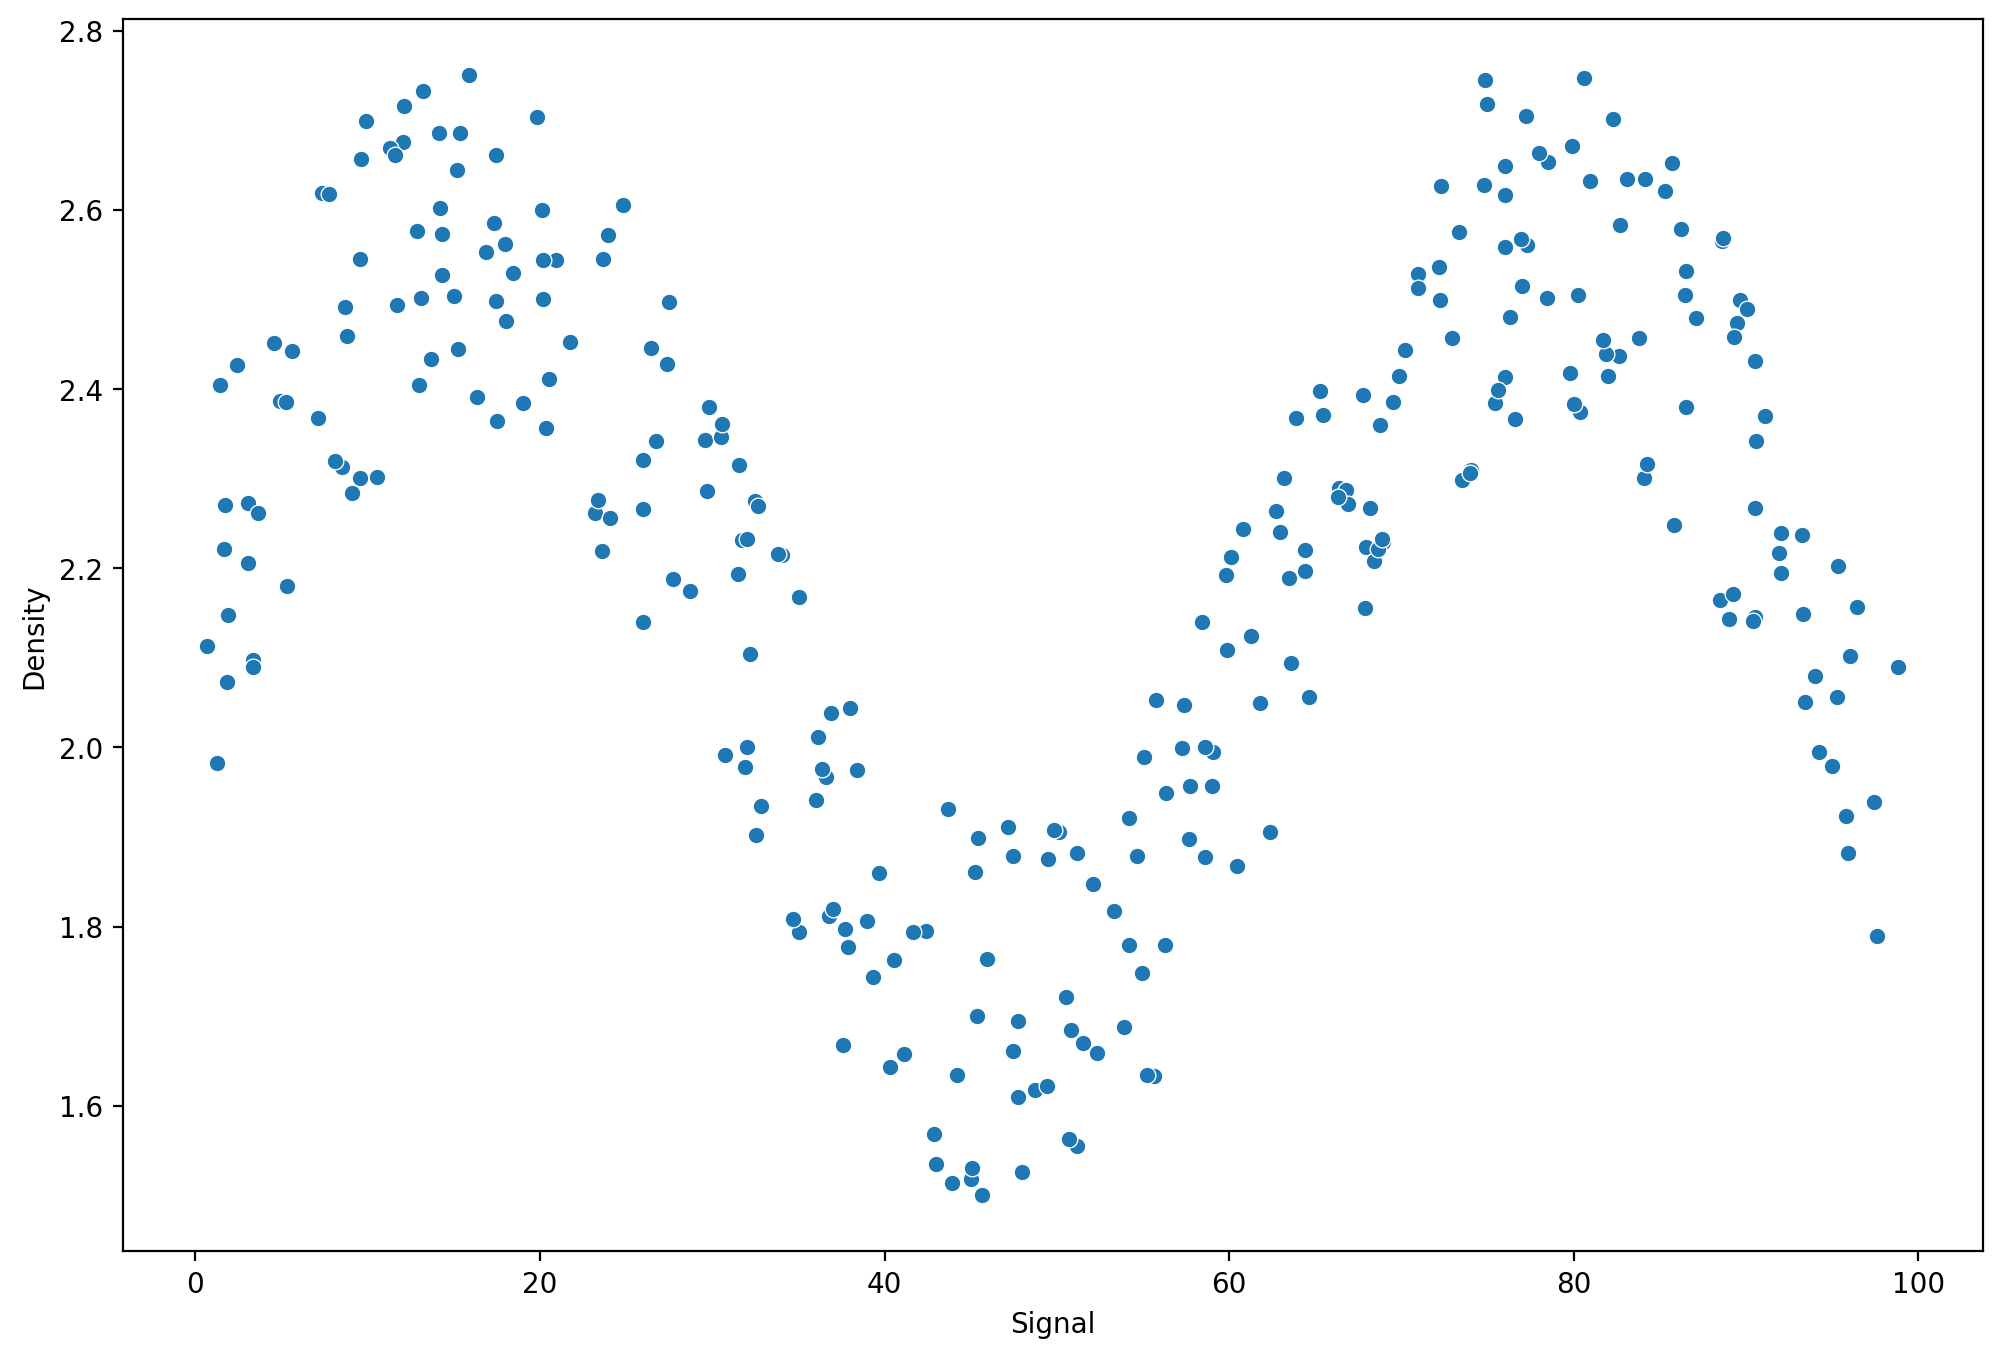

In [5]:
plt.figure(figsize=(12,8),dpi=200)
sns.scatterplot(x='Signal',y='Density',data=df)

---
---

## Splitting the Data

Let's split the data in order to be able to have a Test set for performance metric evaluation.

In [6]:
X = df['Signal'].values.reshape(-1,1)
# In this we only have selecting one column, so we can use .values to get the values of that column and then reshape it to be a 2D array with one column and as many rows as there are samples in the dataset. This is necessary because many machine learning algorithms expect the input data to be in a 2D format, where each row represents a sample and each column represents a feature.
# Also we need to reshape the data because the original shape of the 'Signal' column is a 1D array, and we need to convert it to a 2D array with one column to be compatible with the machine learning algorithms that we will be using later on.
# Important note: Like we are taking only 1 column we can avoid scale the data, because the scale of the data will not affect the performance of the model when we are using only one feature. However, if we were using multiple features with different scales, it would be important to scale the data to ensure that all features are on a similar scale and that the model is not biased towards features with larger scales.
y = df['Density']

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

-----

# Linear Regression

In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
lr_model = LinearRegression()

In [11]:
lr_model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
lr_preds = lr_model.predict(X_test)

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [21]:
df['Density'].mean()

np.float64(2.225062949323796)

In [19]:
mean_absolute_error(y_test, lr_preds)

0.211198973318633

In [ ]:
np.sqrt(mean_squared_error(y_test,lr_preds))
# So We're getting about 10% error here and there is some deviation, but it's nothing too extreme. 
# You actually can think that linear regression is on avergare performing quite well, and that's really the heart of the problem on average.

np.float64(0.2570051996584629)

What does the fit look like?

In [15]:
signal_range = np.arange(0,100)

In [16]:
lr_output = lr_model.predict(signal_range.reshape(-1,1))

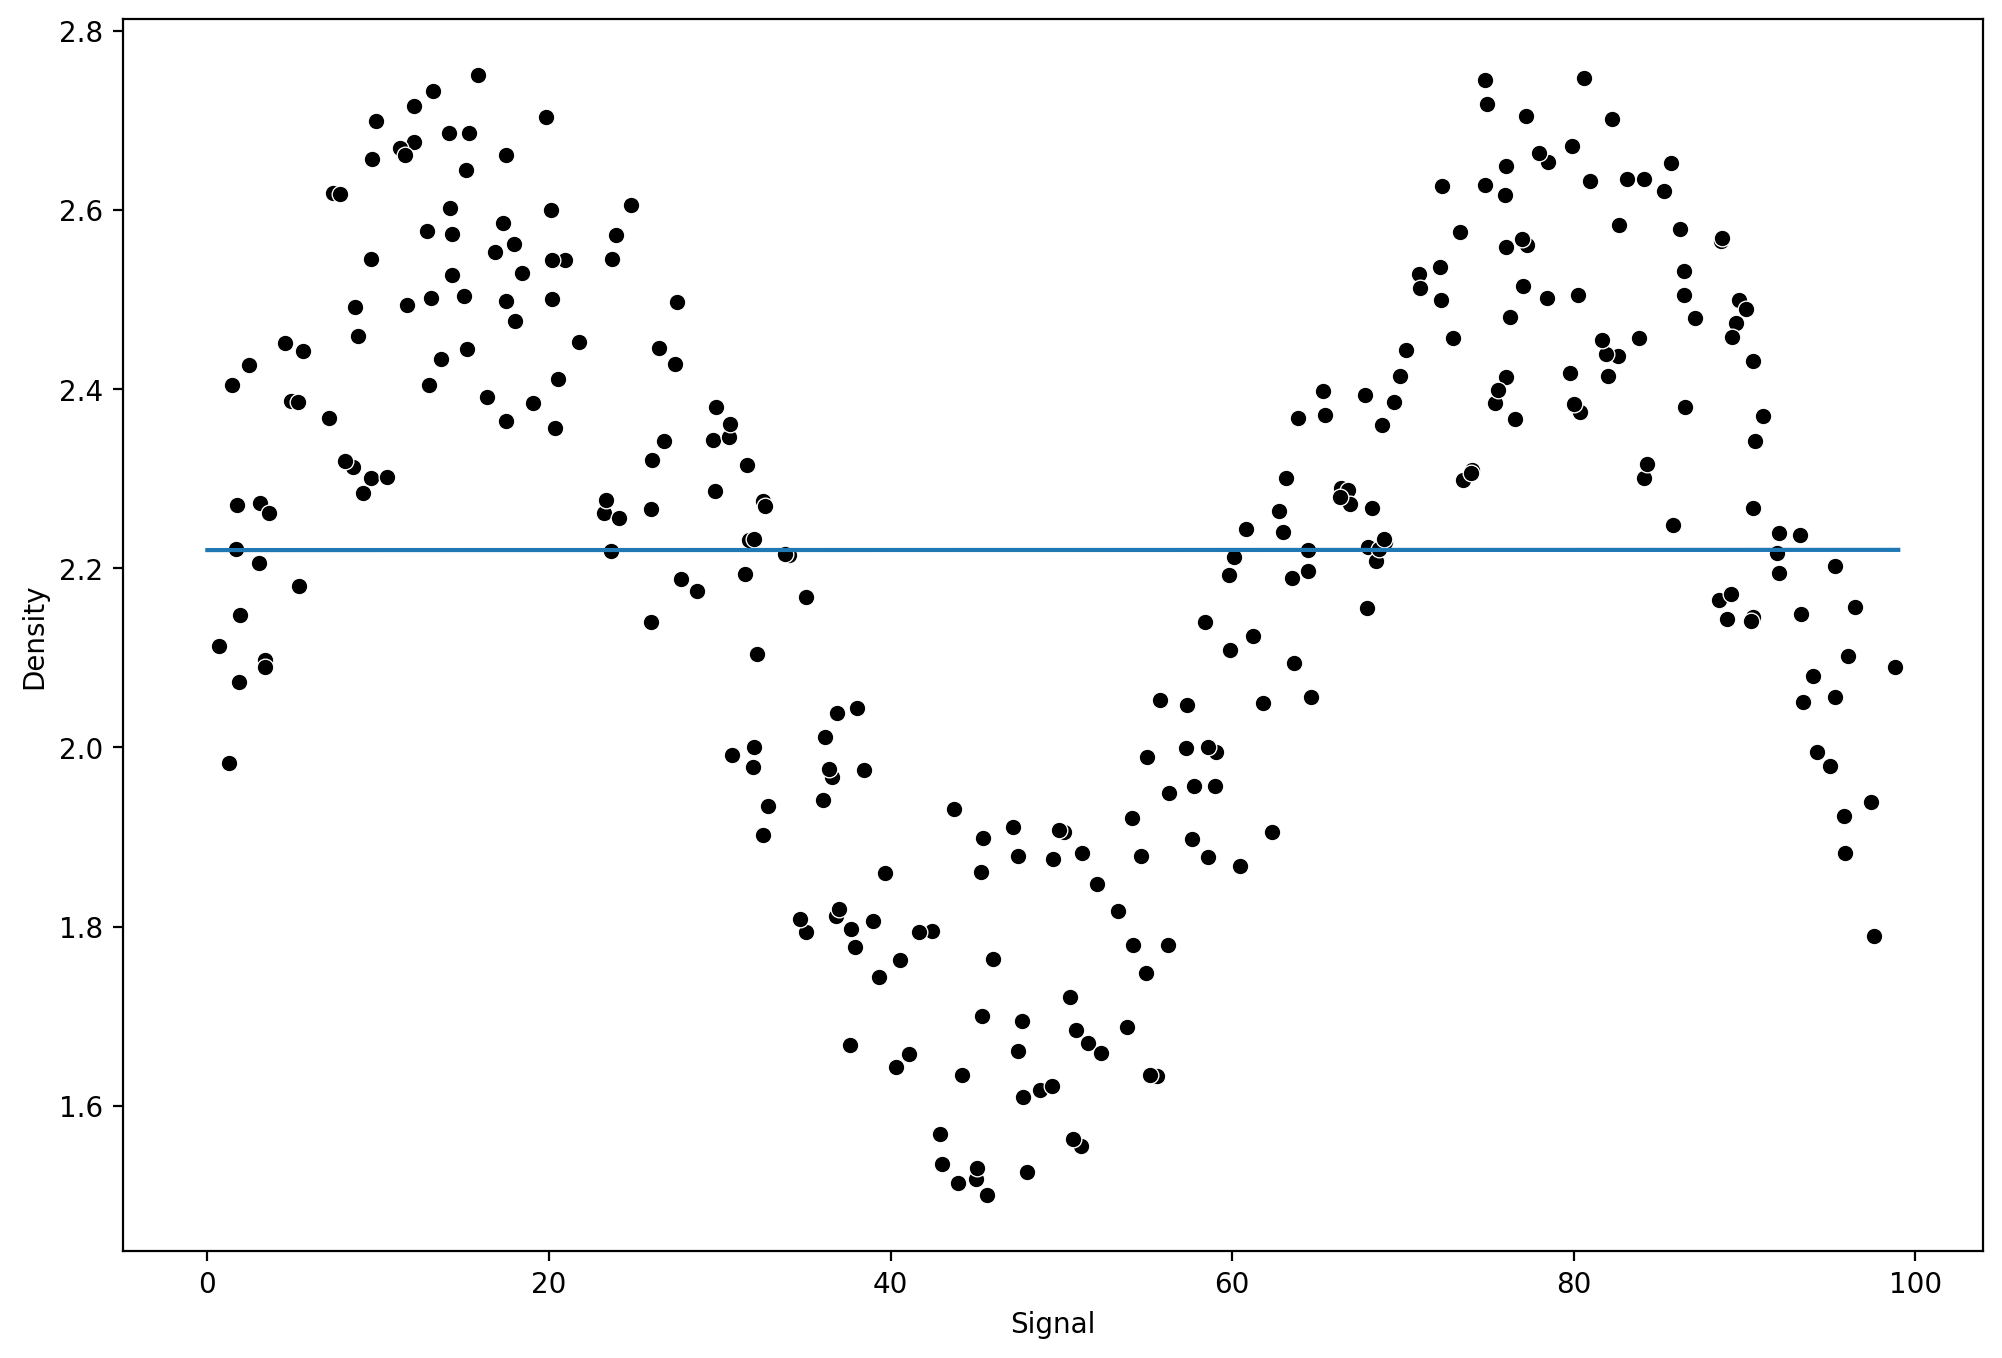

In [ ]:
plt.figure(figsize=(12,8),dpi=200)
sns.scatterplot(x='Signal',y='Density',data=df,color='black')
plt.plot(signal_range,lr_output)
# As you can see in the plot above, the linear regression model is not able to capture the non-linear relationship between the signal and density. 
# The model is trying to fit a straight line to the data, which results in a poor fit and high error. 
# This is a common issue with linear regression when dealing with non-linear data, and it highlights the importance of choosing the right model for the problem at hand. 
# In this case, we may want to consider using a more flexible model, such as a random forest regression, which can capture non-linear relationships in the data.

---

# Polynomial Regression

## Attempting with a Polynomial Regression Model

Let's explore why our standard regression approach of a polynomial could be difficult to fit here, keep in mind, we're in a fortunate situation where we can easily visualize results of y vs x.

## Function to Help Run Models

In [22]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [23]:
def run_model(model,X_train,y_train,X_test,y_test):
    
    # Fit Model
    model.fit(X_train,y_train)
    
    # Get Metrics
    
    preds = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test,preds))
    mae = mean_absolute_error(y_test,preds)
    print(f'MAE : {mae}')
    print(f'RMSE : {rmse}')
    
    # Plot results
    signal_range = np.arange(0,100)
    output = model.predict(signal_range.reshape(-1,1))
    
    
    plt.figure(figsize=(12,6),dpi=150)
    sns.scatterplot(x='Signal',y='Density',data=df,color='black')
    plt.plot(signal_range,output)

MAE : 0.211198973318633
RMSE : 0.2570051996584629


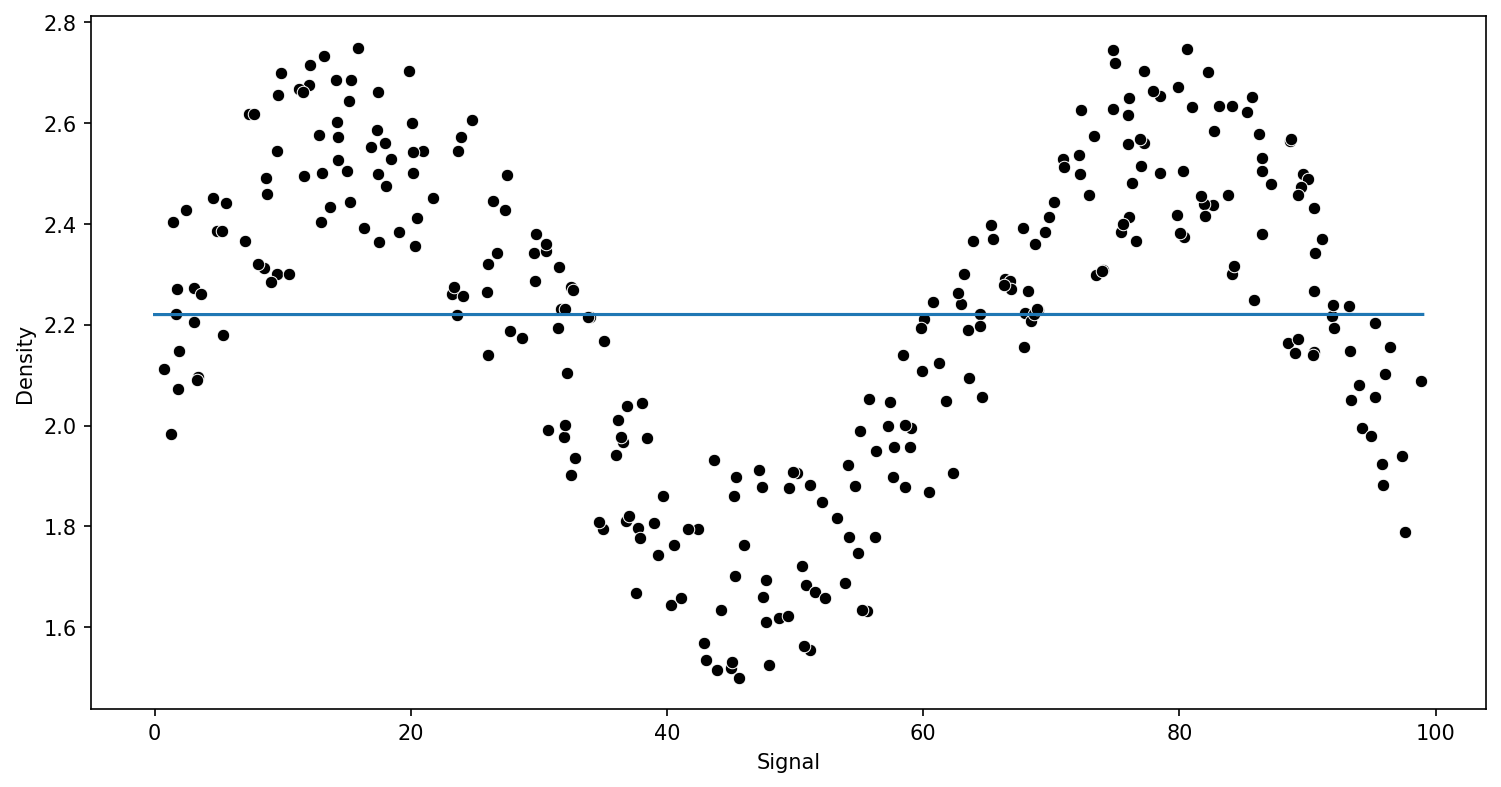

In [24]:
run_model(model,X_train,y_train,X_test,y_test)

## Pipeline for Poly Orders

In [25]:
from sklearn.pipeline import make_pipeline

In [26]:
from sklearn.preprocessing import PolynomialFeatures

In [27]:
pipe = make_pipeline(PolynomialFeatures(2),LinearRegression())

MAE : 0.22903105443511176
RMSE : 0.2817309563725547


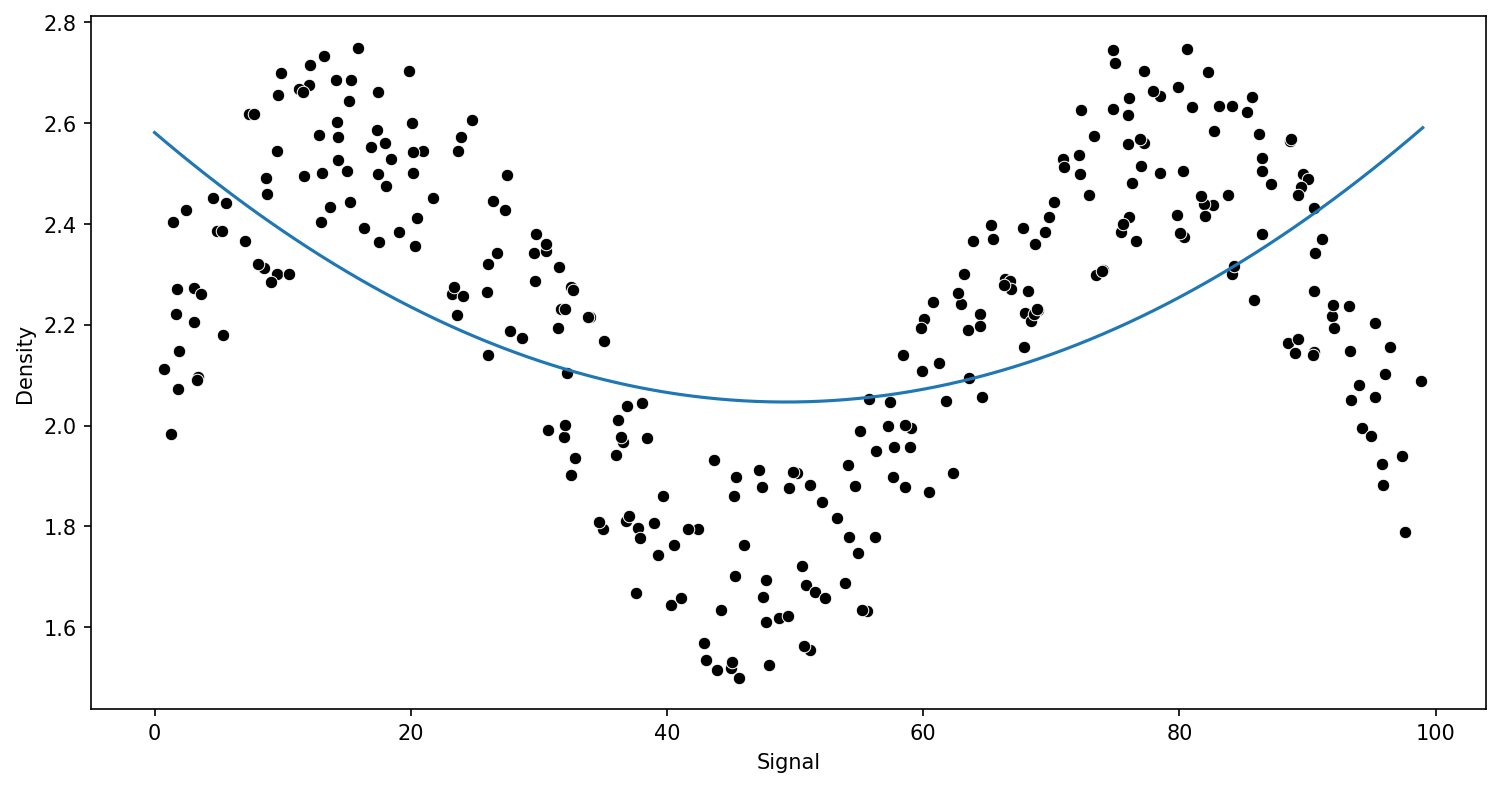

In [ ]:
run_model(pipe,X_train,y_train,X_test,y_test)

## Comparing Various Polynomial Orders

MAE : 0.14338577193825677
RMSE : 0.1626900529281319


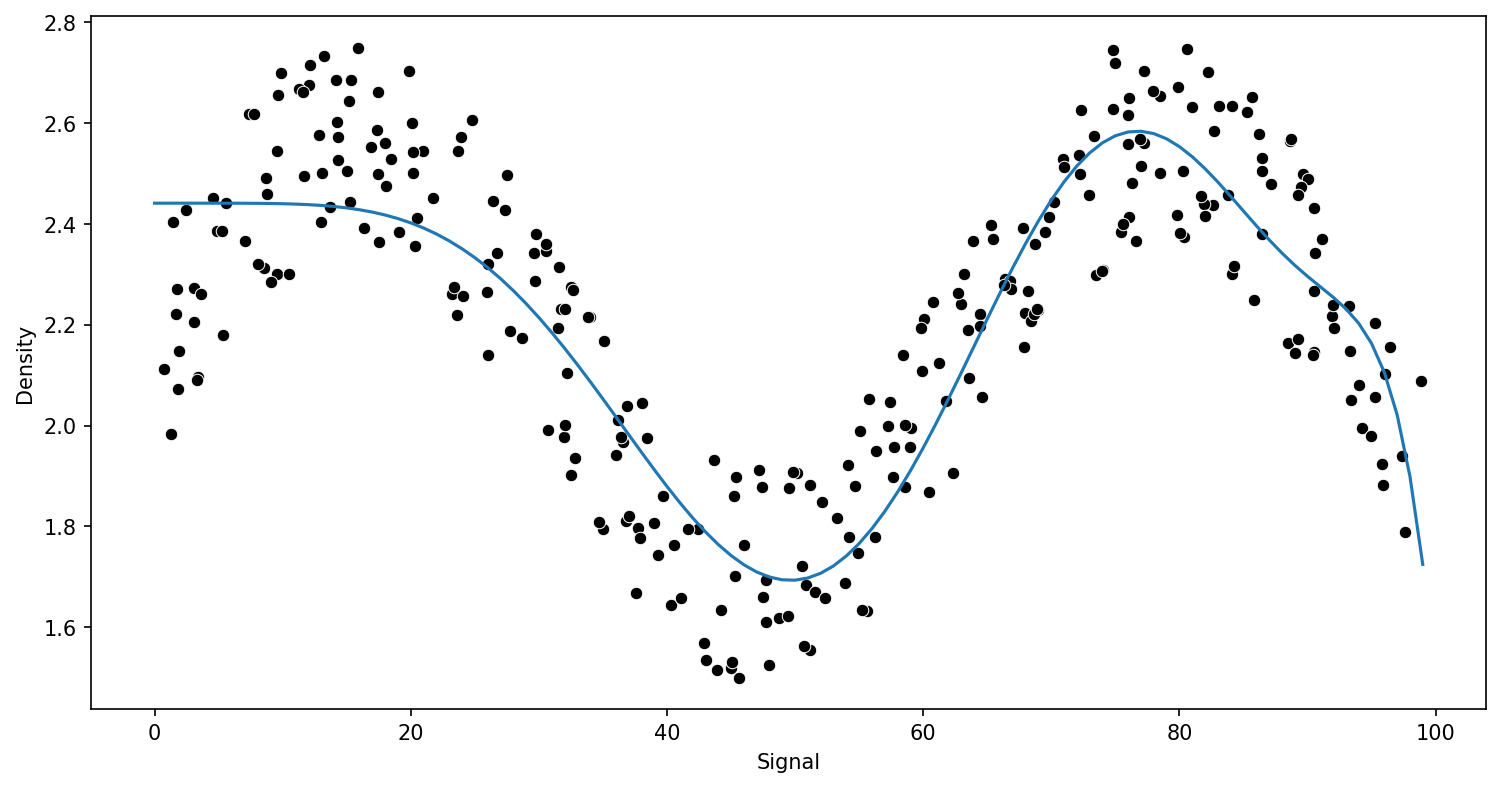

In [ ]:
pipe = make_pipeline(PolynomialFeatures(10),LinearRegression())
run_model(pipe,X_train,y_train,X_test,y_test)
# Now this is a great example for you to play around with for the bias variance tradeoff, 
# This is the sort of situation you have to be extremely careful about when interpreting your performance metrics.
# because as you get to higher and higher levels for this polynomial regression, you can see that the error is going down significantly, but now I'm gonna start picking up on a lot more variance here.
# So this is a great example of the bias variance tradeoff, where as you increase the complexity of the model, you can reduce the bias and get a better fit to the training data, but at the same time, you can also increase the variance and start to overfit the data.
# So notice that as we get to higher and higher levels for this polynomial regression, the error is going down significantly, but now we're starting to pick up on a lot more noise here.

MAE : 0.1196911505437652
RMSE : 0.13807435345557376


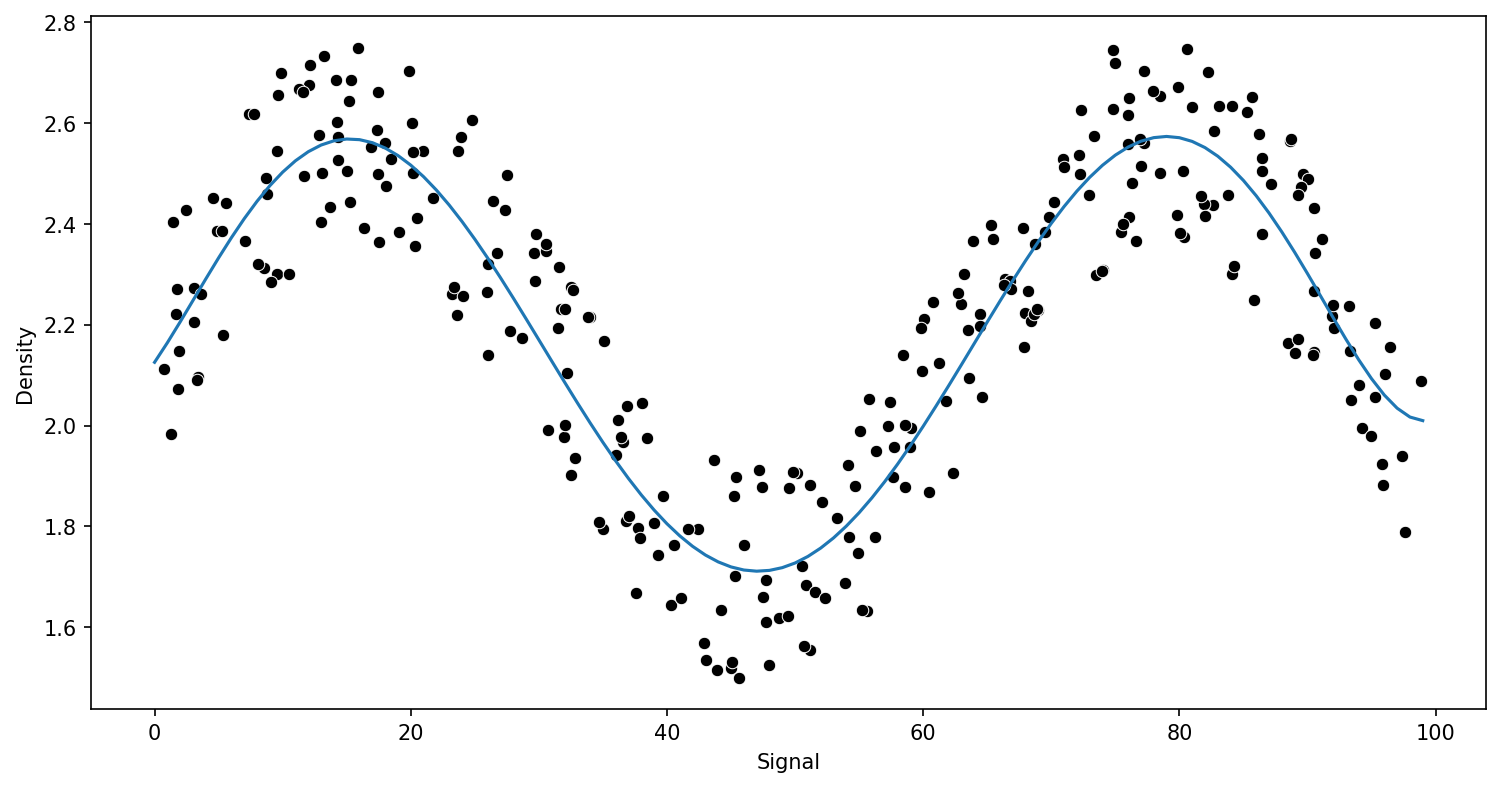

In [ ]:
pipe = make_pipeline(PolynomialFeatures(6),LinearRegression())
run_model(pipe,X_train,y_train,X_test,y_test)
# As we can see the 6 degree polynomial regression is performing much better than the 10 degree polynomial regression, and it's also performing better than the linear regression model.
# Now we can see that the 6 degree polynomial regression is performing much better than the 10 degree polynomial regression, and it's also performing better than the linear regression model. 
# This is a great example of how increasing the complexity of the model can lead to better performance, but at the same time, 
# it can also lead to overfitting if we go too far with the complexity. 
# It's important to find the right balance between bias and variance when choosing a model for a given problem.

----

## KNN Regression

In [31]:
from sklearn.neighbors import KNeighborsRegressor

MAE : 0.11877297474442378
RMSE : 0.1523487028635337
MAE : 0.12198383614100558
RMSE : 0.13730685016923647
MAE : 0.11635971693292672
RMSE : 0.13277855732740926
MAE : 0.12878322504026188
RMSE : 0.151321497164368
MAE : 0.1570937980156112
RMSE : 0.19545005360281248
MAE : 0.16671472141169144
RMSE : 0.21309029683672812


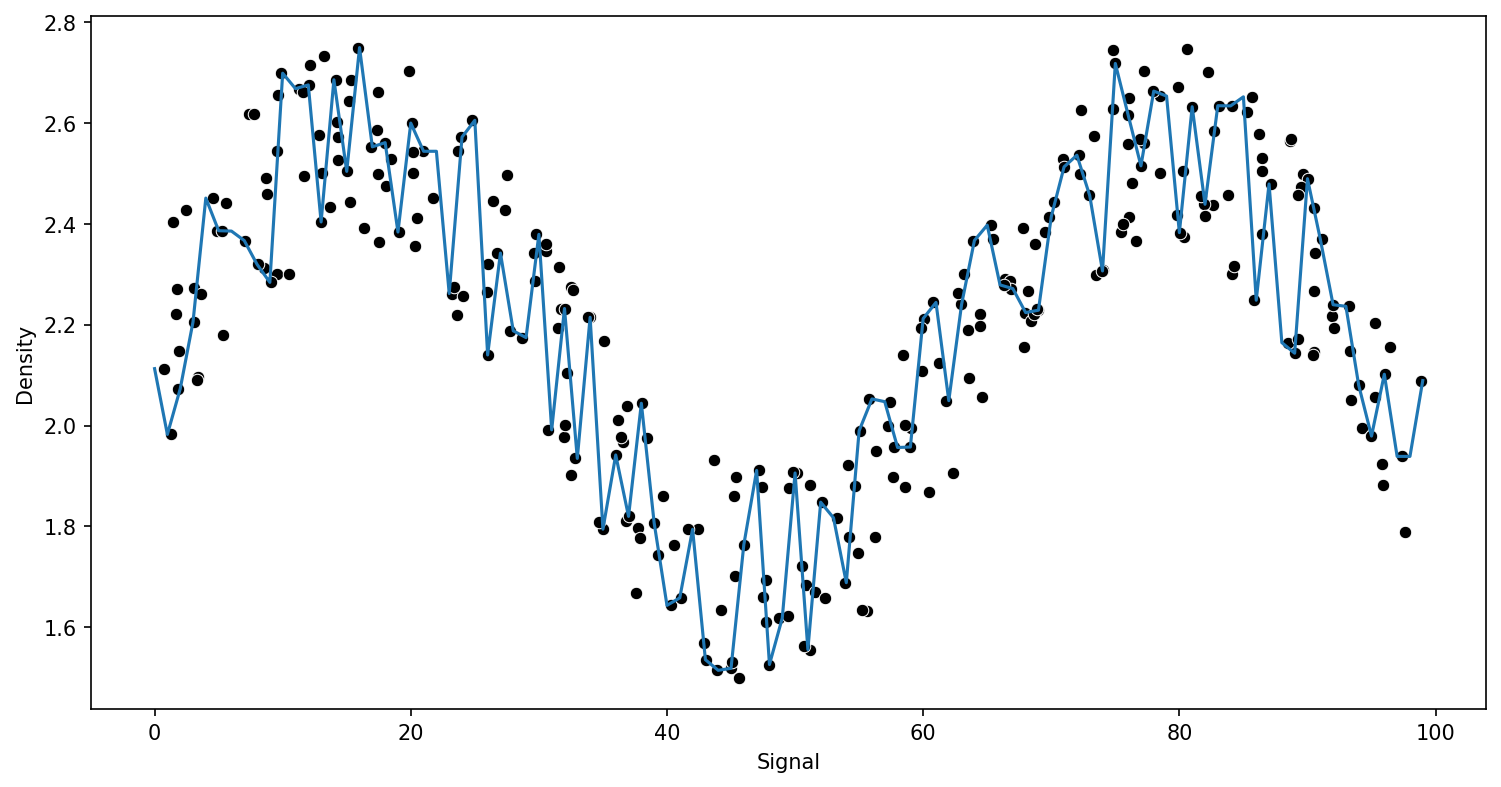

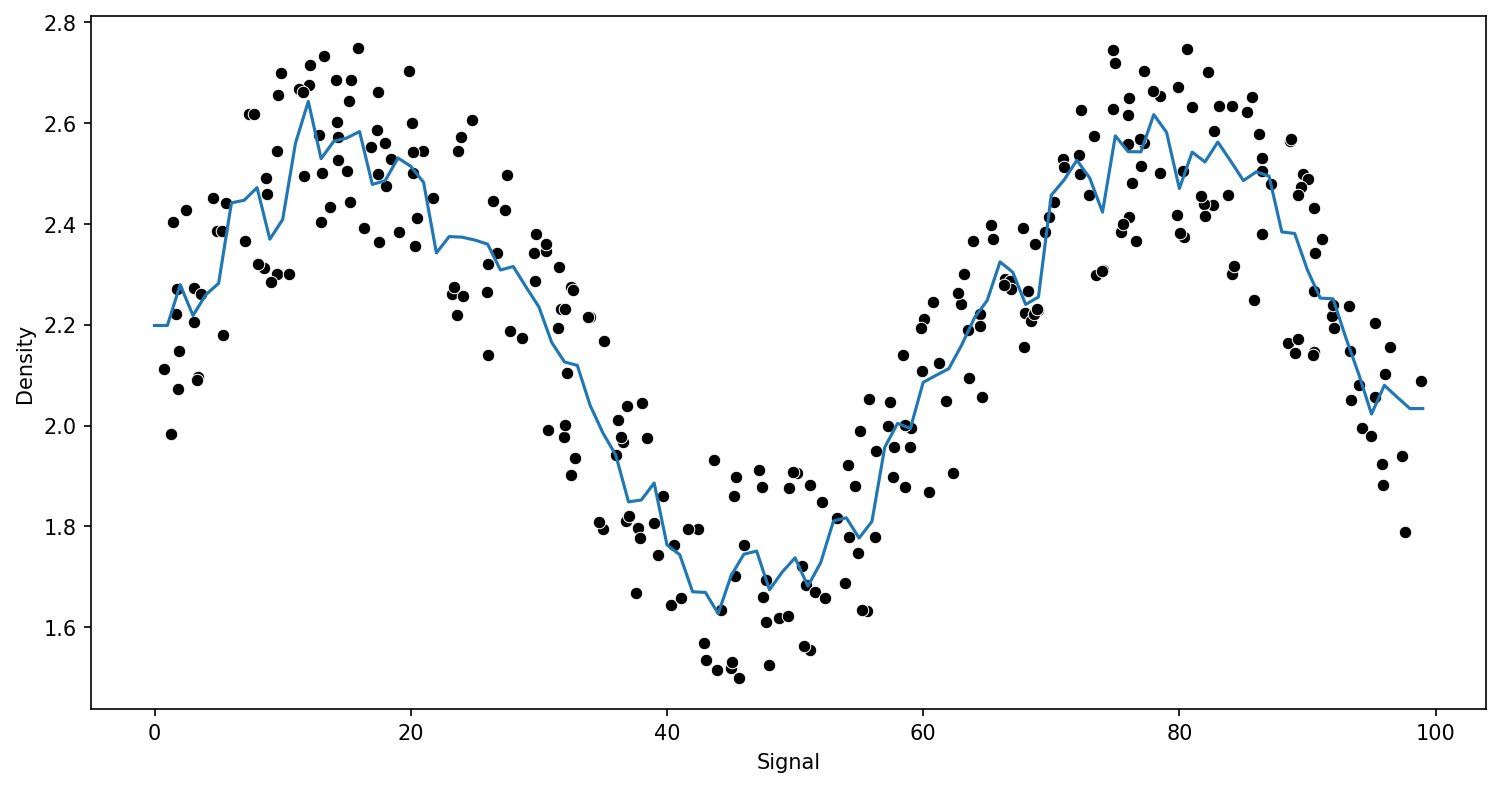

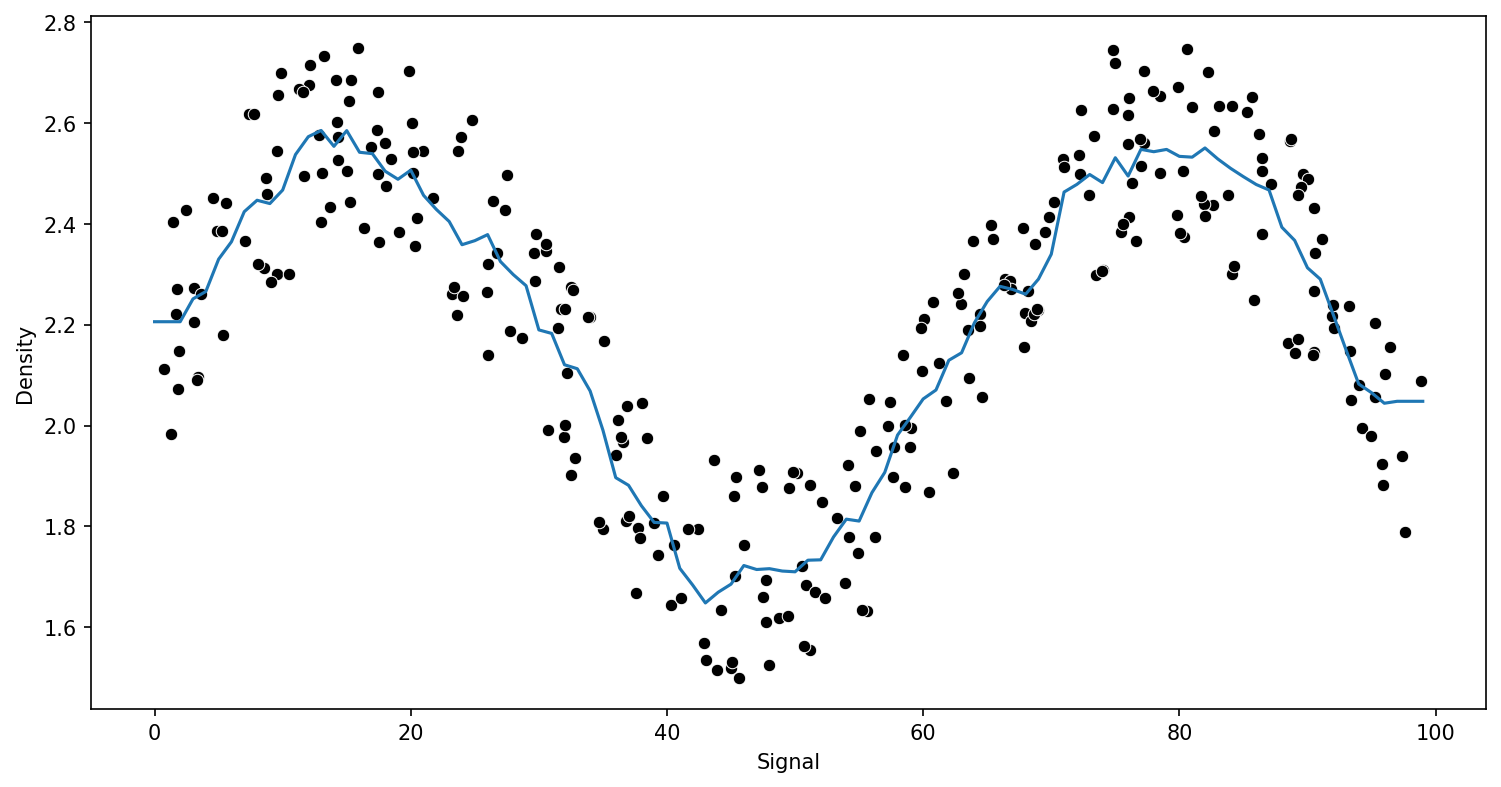

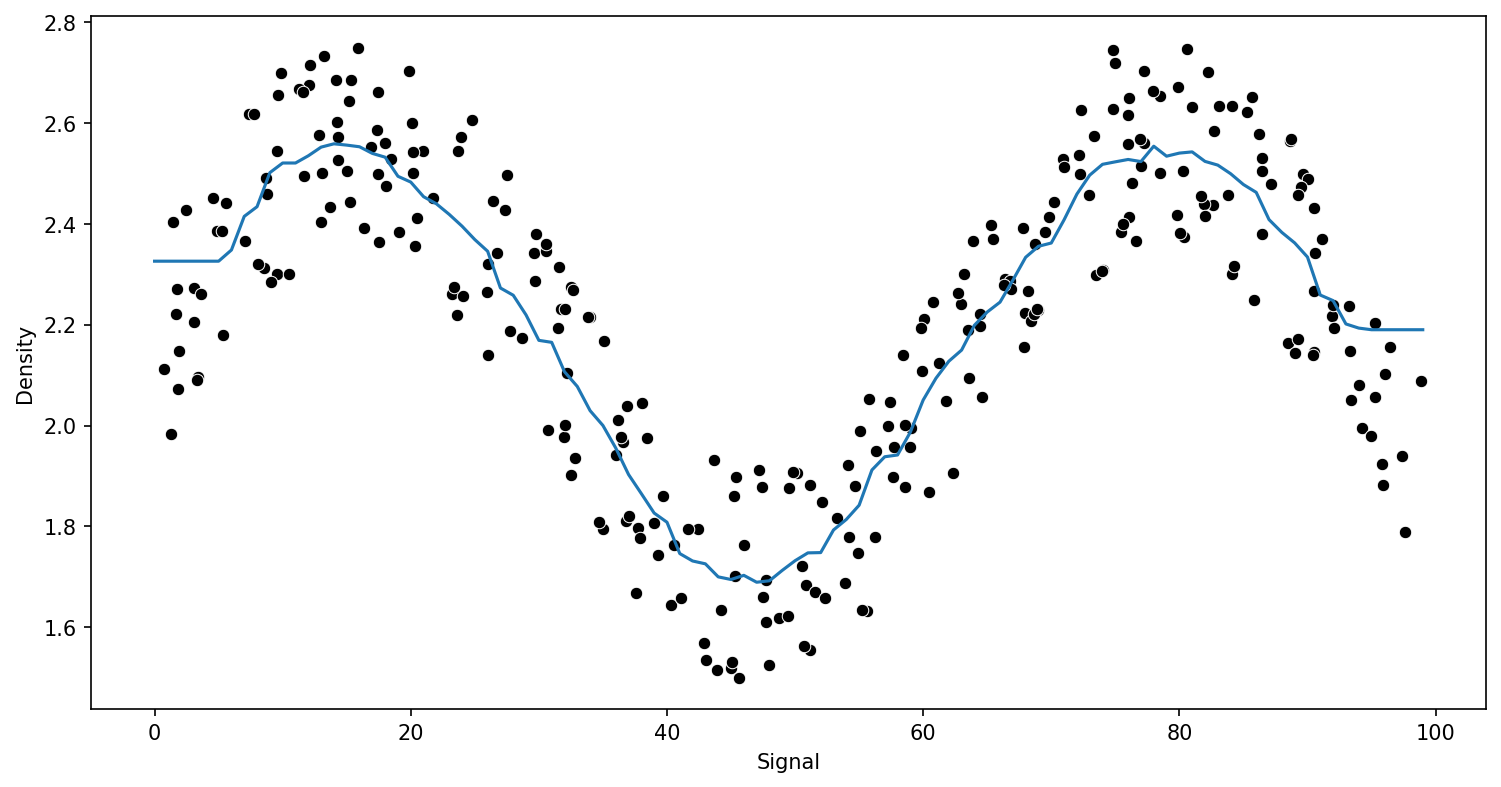

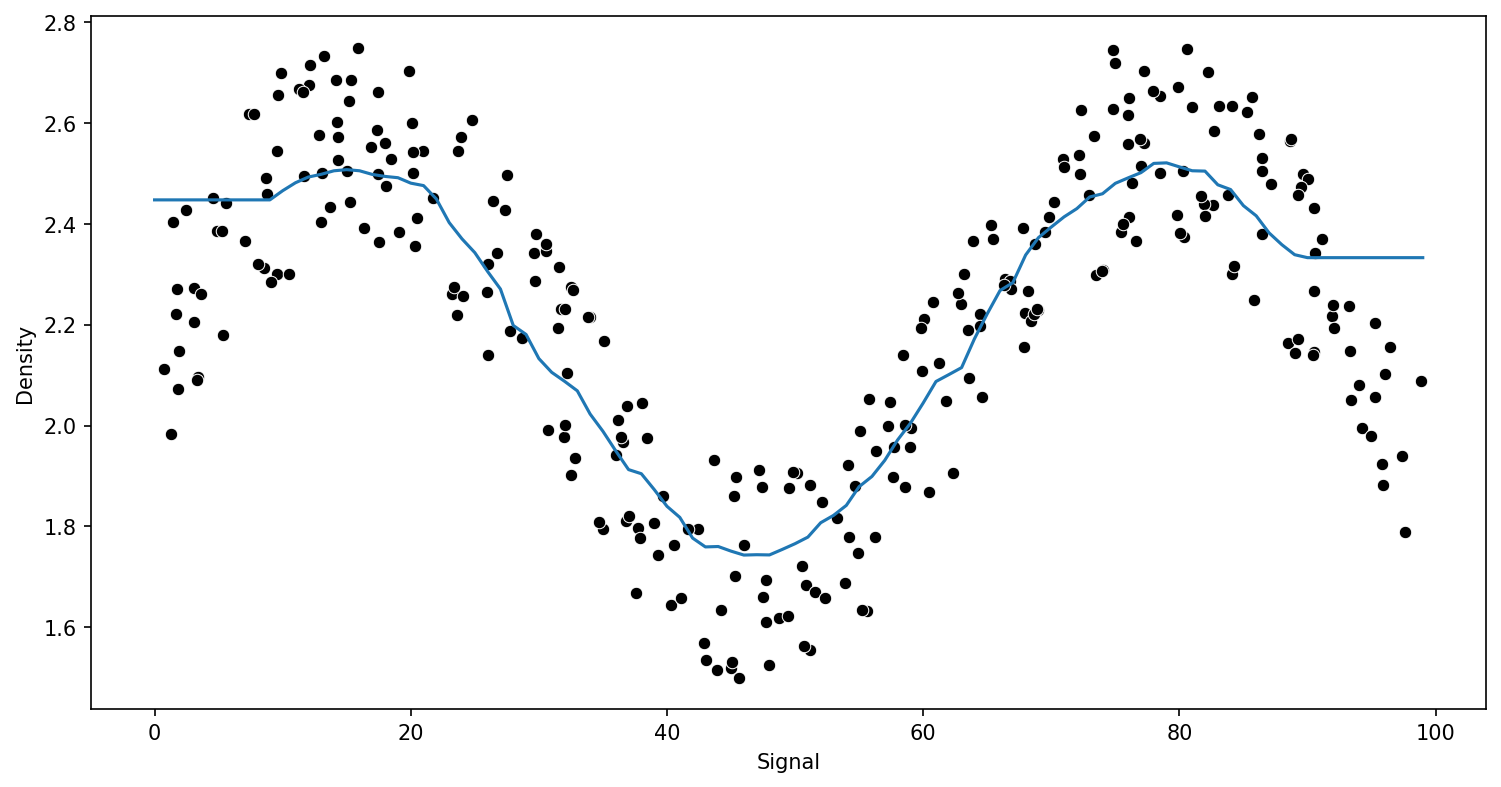

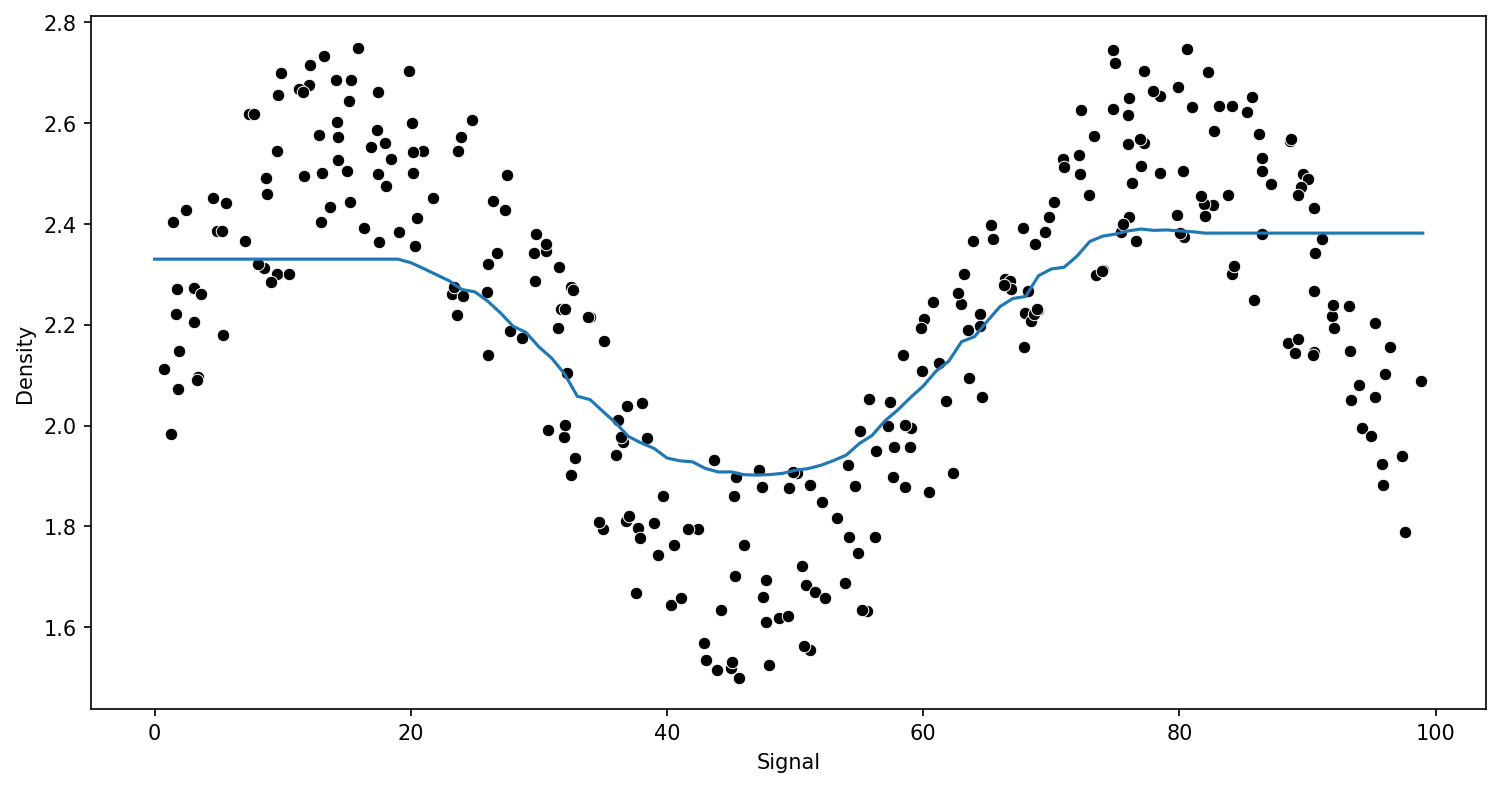

In [32]:
preds = {}
k_values = [1,5,10, 25, 50, 100]
for n in k_values:
    
    
    model = KNeighborsRegressor(n_neighbors=n)
    run_model(model,X_train,y_train,X_test,y_test)

---
## Decision Tree Regression

In [33]:
from sklearn.tree import DecisionTreeRegressor

MAE : 0.11877297474442378
RMSE : 0.1523487028635337


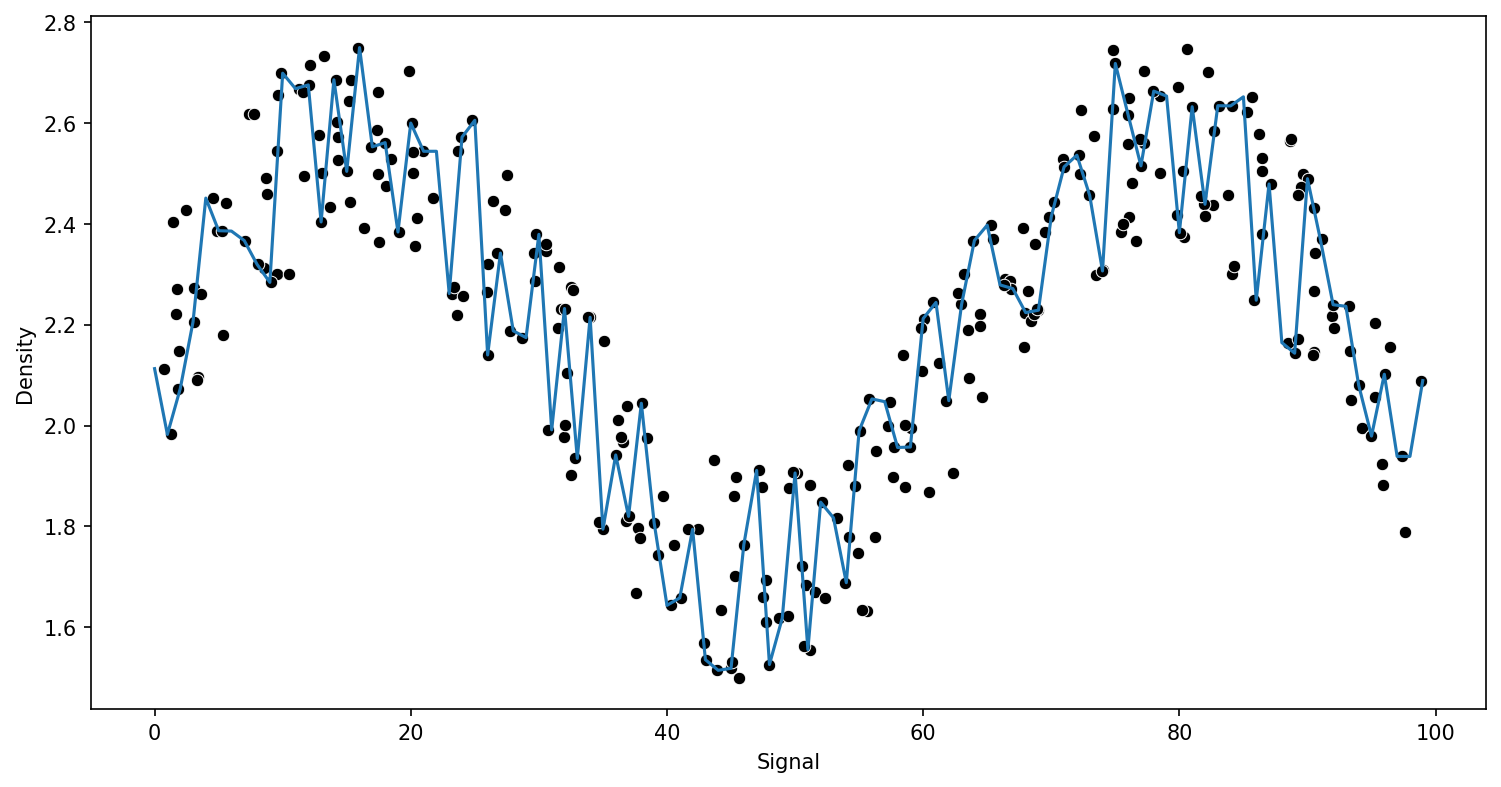

In [34]:
model = DecisionTreeRegressor()

run_model(model,X_train,y_train,X_test,y_test)

In [35]:
model.get_n_leaves()

np.int64(270)

----

## Support Vector Regression

In [36]:
from sklearn.svm import SVR

In [37]:
from sklearn.model_selection import GridSearchCV

In [38]:
param_grid = {'C':[0.01,0.1,1,5,10,100,1000],'gamma':['auto','scale']}
svr = SVR()

In [39]:
grid = GridSearchCV(svr,param_grid)

MAE : 0.10854210121348368
RMSE : 0.12646999302046696


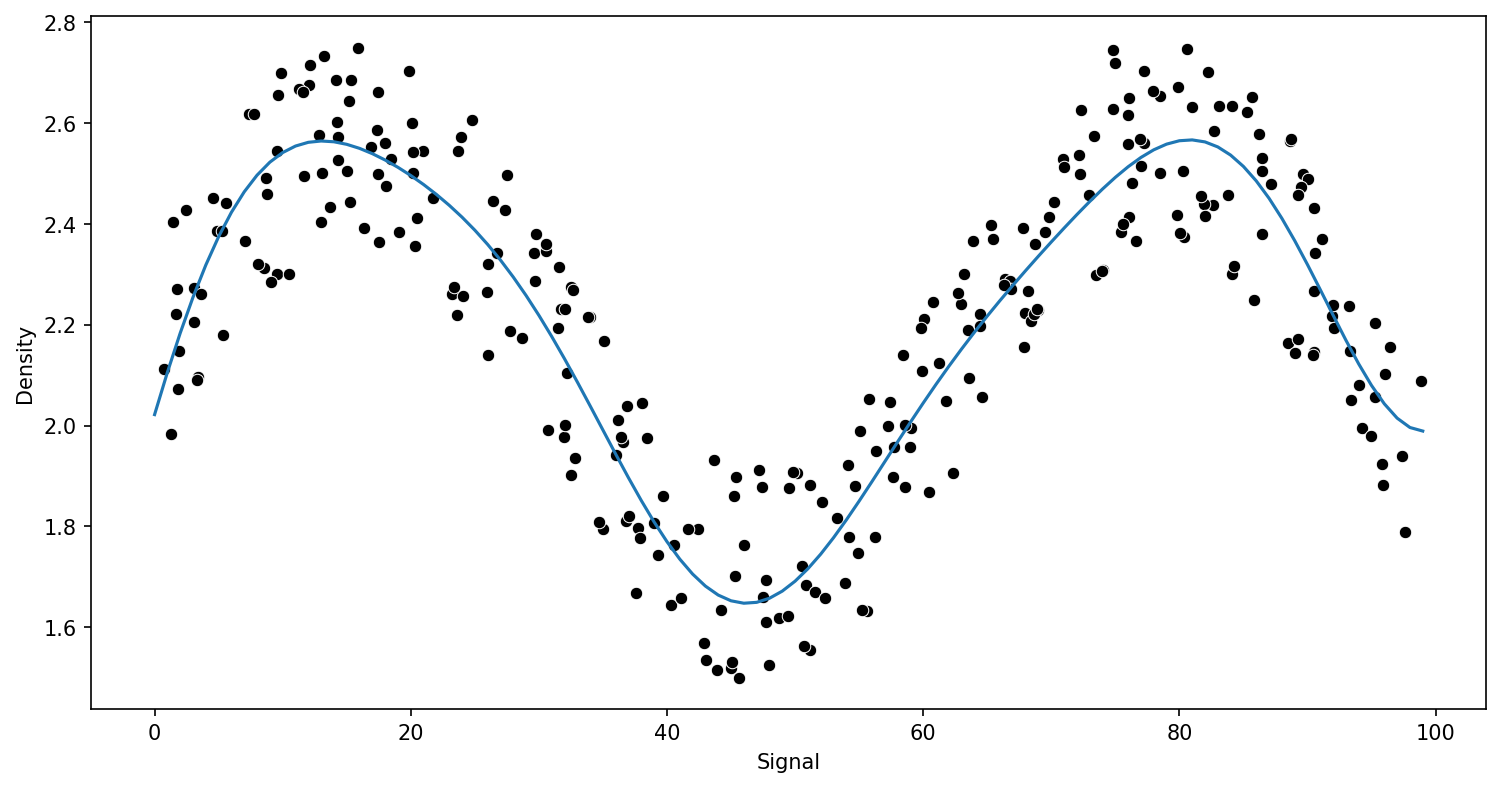

In [40]:
run_model(grid,X_train,y_train,X_test,y_test)

In [41]:
grid.best_estimator_

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1000
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [42]:
grid.best_params_

{'C': 1000, 'gamma': 'scale'}

---

## Random Forest Regression

In [43]:
from sklearn.ensemble import RandomForestRegressor

In [289]:
# help(RandomForestRegressor)

MAE : 0.11888223634815594
RMSE : 0.14291999441517825
MAE : 0.10909659658119794
RMSE : 0.1325072930762745
MAE : 0.1092275821560451
RMSE : 0.13241234472968005


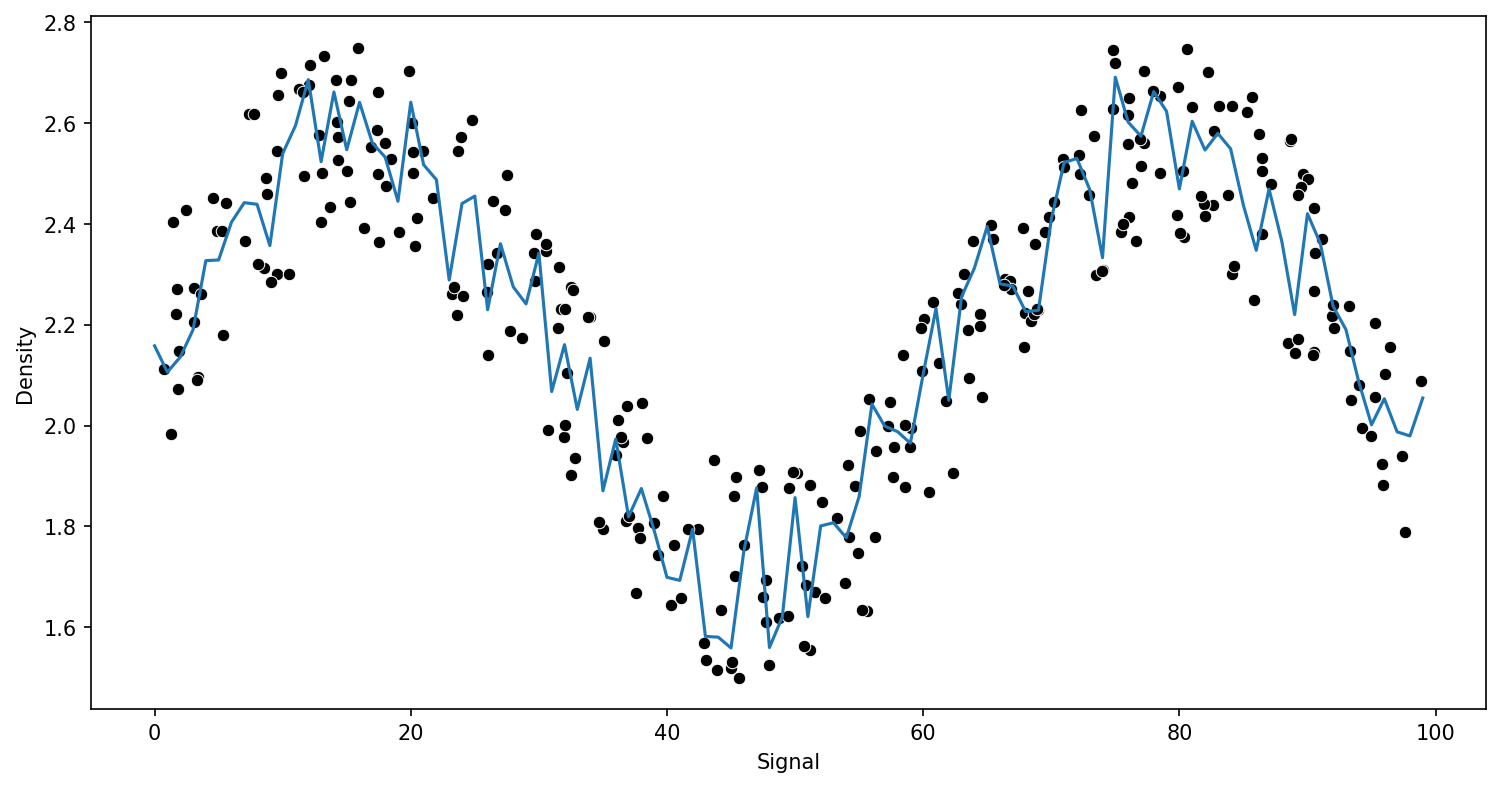

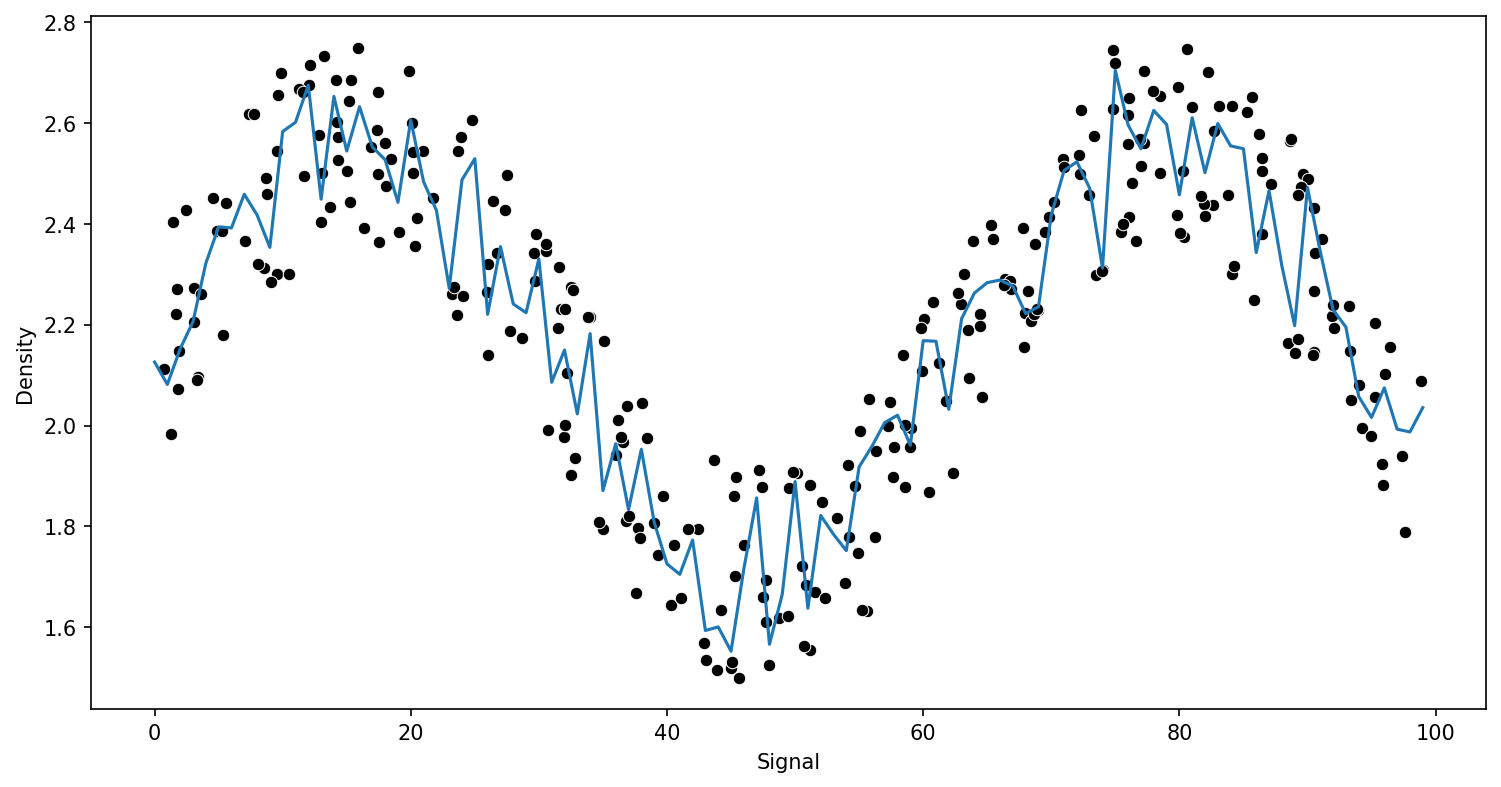

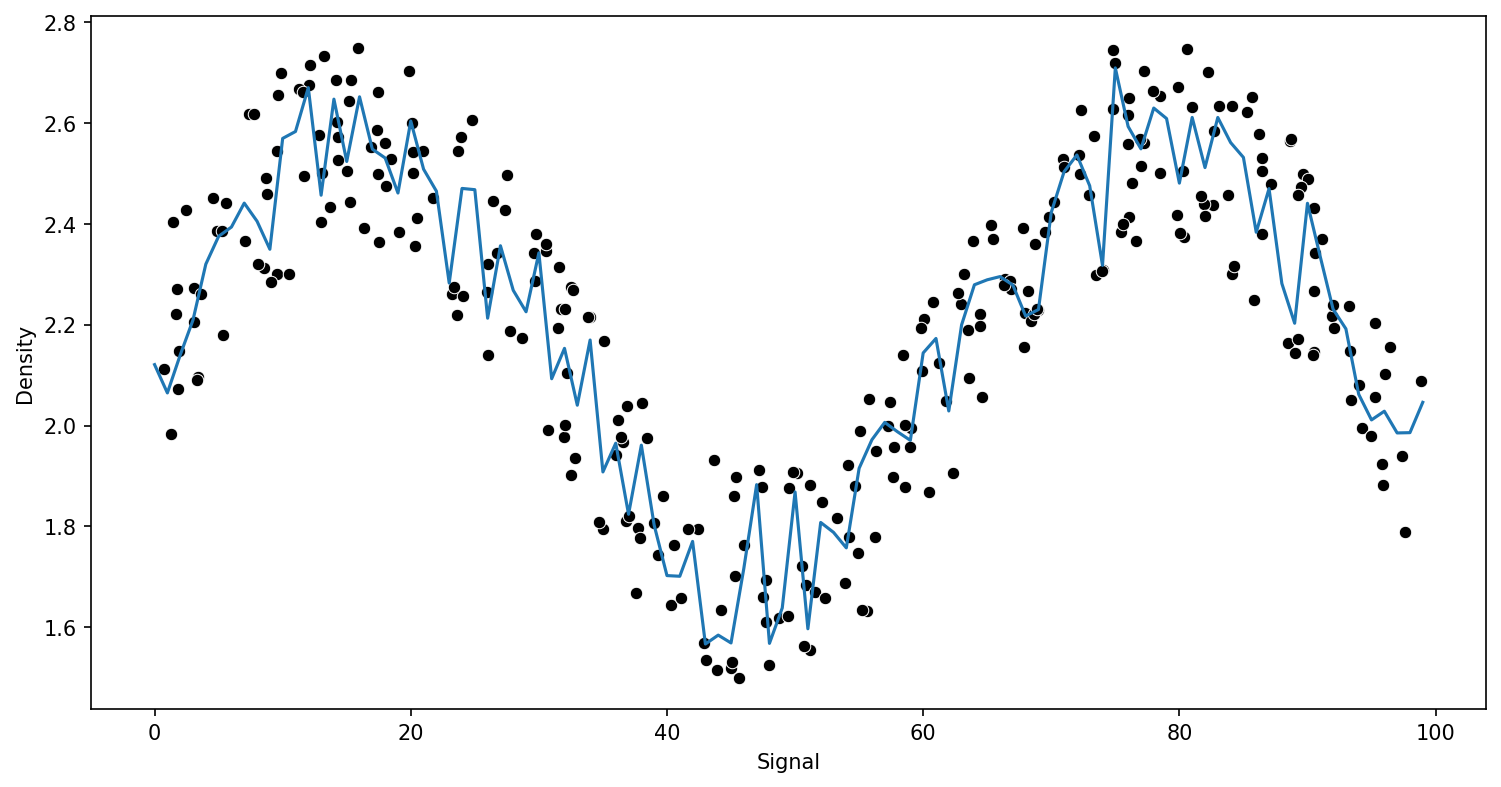

In [44]:
trees = [10,50,100]
for n in trees:
    
    model = RandomForestRegressor(n_estimators=n)
    
    run_model(model,X_train,y_train,X_test,y_test)

## Gradient Boosting

We will cover this in more detail in next section.

In [45]:
from sklearn.ensemble import GradientBoostingRegressor

In [46]:
# help(GradientBoostingRegressor)

MAE : 0.11318284854800689
RMSE : 0.13294148649584667


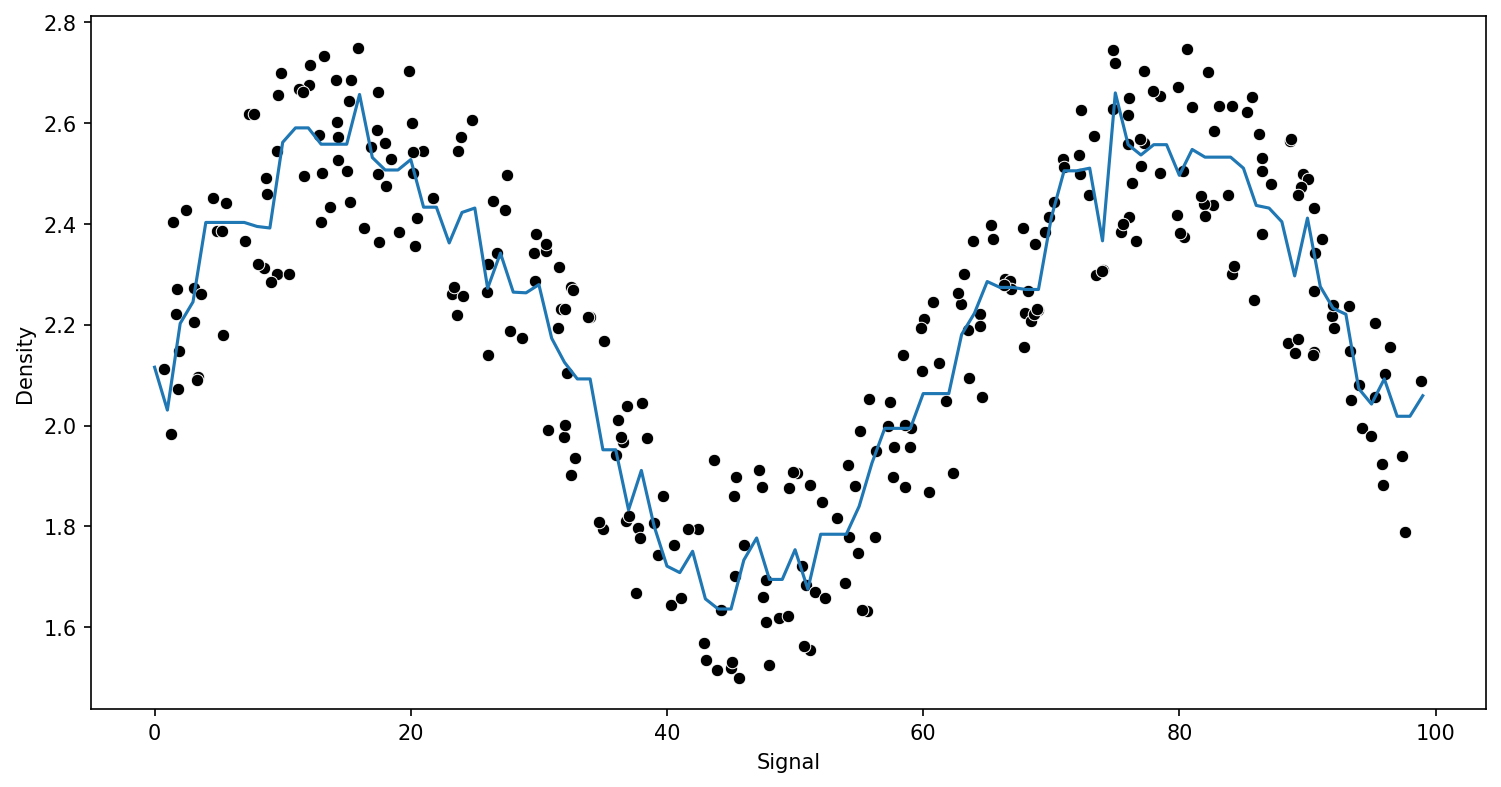

In [47]:
   
model = GradientBoostingRegressor()

run_model(model,X_train,y_train,X_test,y_test)

## Adaboost

In [48]:
from sklearn.ensemble import AdaBoostRegressor

MAE : 0.11574437755583188
RMSE : 0.13448260264638726


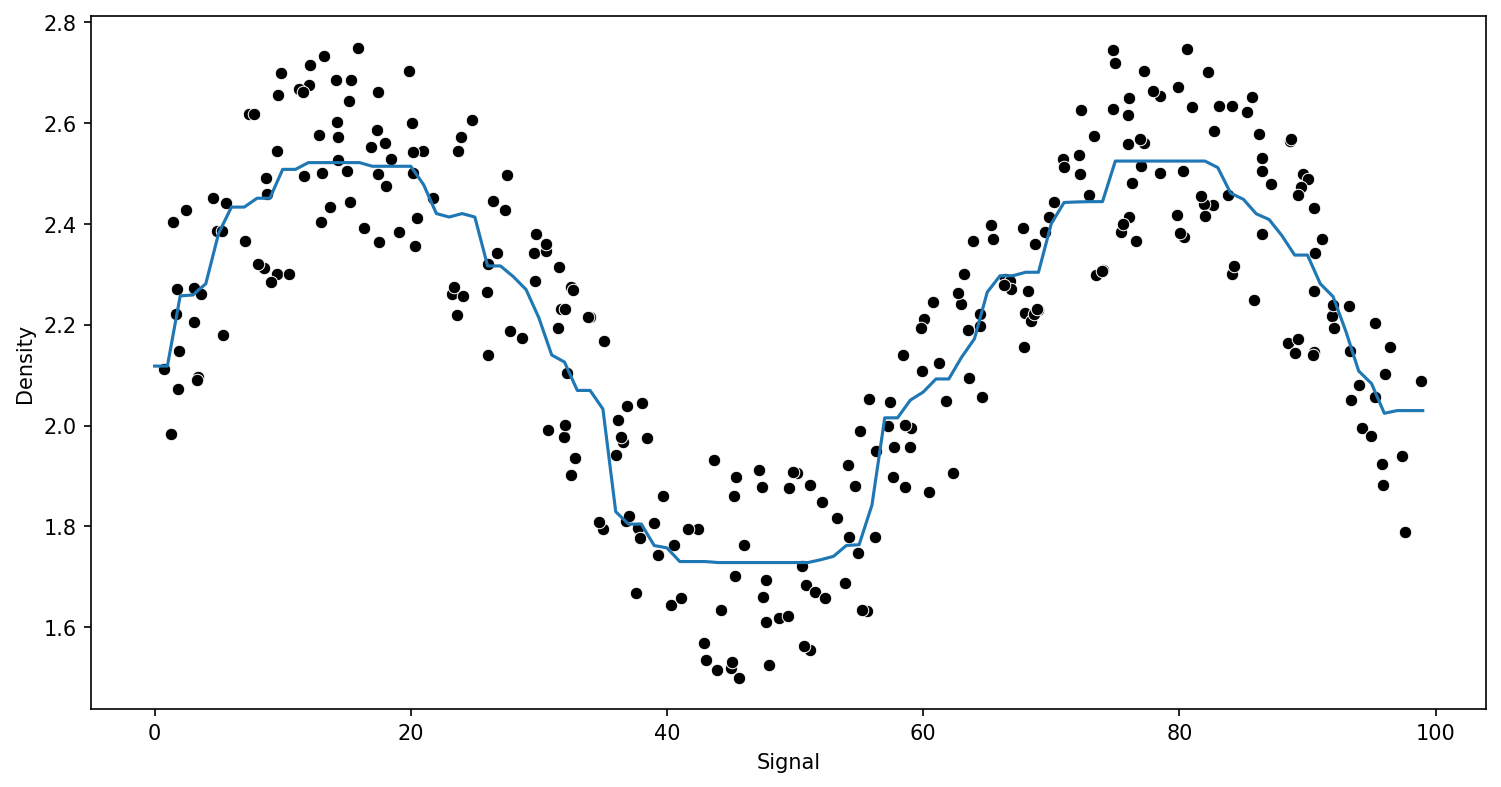

In [49]:
model = AdaBoostRegressor()

run_model(model,X_train,y_train,X_test,y_test)

----